# Model Comparison: Accuracy + Confusion Matrices

**Models compared:**
1. VADER (lexicon)
2. TF-IDF + Logistic Regression
3. Hybrid SVM + Lexicon
4. FinBERT Baseline
5. FinBERT Finetuned ← best model

## Install & Imports

In [ ]:
!pip install transformers torch scikit-learn vaderSentiment seaborn matplotlib joblib --quiet
import nltk
nltk.download('vader_lexicon', quiet=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.7 MB/s eta 0:00:00


True

In [ ]:
import pandas as pd
import numpy as np
import torch
import joblib
import re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from nltk.sentiment import SentimentIntensityAnalyzer
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LABELS = ['negative', 'neutral', 'positive']
print(f'Device: {DEVICE}')

Device: cuda


## 1. Load & Split Data
> Uses the **same** balanced 9000-row dataset and same random seed as your original notebook so results are directly comparable.

In [ ]:
df = pd.read_csv('articles.csv')
df.columns = [c.strip() for c in df.columns]

# Balance to 3000 per class (same as original)
df_balanced = (
    df.groupby('Sentiment', group_keys=False)
      .apply(lambda x: x.sample(min(len(x), 3000), random_state=42))
      .reset_index(drop=True)
)
df_balanced['Sentiment'] = df_balanced['Sentiment'].str.strip().str.lower()

# Same 70/15/15 split as original
X_train, X_temp, y_train, y_temp = train_test_split(
    df_balanced['Sentence'], df_balanced['Sentiment'],
    test_size=0.30, random_state=42, stratify=df_balanced['Sentiment']
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')
print(pd.Series(y_test).value_counts())

Train: 3998 | Val: 857 | Test: 857
Sentiment
neutral     450
positive    278
negative    129
Name: count, dtype: int64


## Helper: Unified Evaluation Function

In [ ]:
# Store results for final comparison
all_results = {}

def evaluate_model(name, y_true, y_pred, color='Blues'):
    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, labels=LABELS, output_dict=True)
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)

    # Store for final comparison chart
    all_results[name] = {
        'accuracy': acc,
        'f1_macro':    report['macro avg']['f1-score'],
        'f1_negative': report['negative']['f1-score'],
        'f1_neutral':  report['neutral']['f1-score'],
        'f1_positive': report['positive']['f1-score'],
    }

    # Print text report
    print('=' * 55)
    print(f'  {name}')
    print('=' * 55)
    print(f'  Accuracy : {acc:.4f} ({acc*100:.2f}%)')
    print(f'  Macro F1 : {report["macro avg"]["f1-score"]:.4f}')
    print()
    print(classification_report(y_true, y_pred, labels=LABELS))

    # Confusion matrix — accuracy in title, NOT overlaid on the chart
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=color,
        xticklabels=LABELS, yticklabels=LABELS,
        linewidths=0.5, linecolor='grey', ax=ax
    )
    ax.set_title(
        f'Confusion Matrix — {name}\nAccuracy: {acc*100:.2f}%',
        fontsize=12, fontweight='bold', pad=14
    )
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    plt.tight_layout()
    plt.show()
    return acc

print('evaluate_model() ready')


evaluate_model() ready


## VADER (Lexicon)

  VADER (Lexicon)
  Accuracy : 0.5123 (51.23%)
  Macro F1 : 0.4790

              precision    recall  f1-score   support

    negative       0.38      0.35      0.36       129
     neutral       0.64      0.48      0.55       450
    positive       0.44      0.64      0.52       278

    accuracy                           0.51       857
   macro avg       0.49      0.49      0.48       857
weighted avg       0.54      0.51      0.51       857



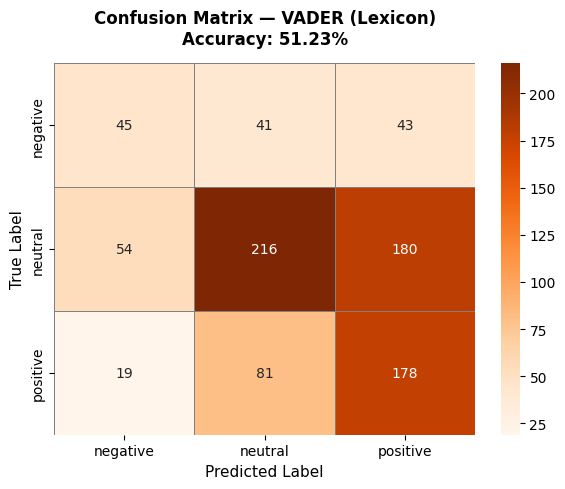

0.5122520420070011

In [ ]:
sia = SentimentIntensityAnalyzer()

def vader_label(text, pos_thresh=0.10, neg_thresh=-0.10):
    compound = sia.polarity_scores(text)['compound']
    if compound >= pos_thresh:   return 'positive'
    elif compound <= neg_thresh: return 'negative'
    else:                        return 'neutral'

y_pred_vader = [vader_label(t) for t in X_test]
evaluate_model('VADER (Lexicon)', y_test, y_pred_vader, color='Oranges')

## TF-IDF + Logistic Regression

  TF-IDF + Logistic Regression
  Accuracy : 0.6651 (66.51%)
  Macro F1 : 0.5496

              precision    recall  f1-score   support

    negative       0.47      0.19      0.27       129
     neutral       0.66      0.86      0.75       450
    positive       0.72      0.56      0.63       278

    accuracy                           0.67       857
   macro avg       0.62      0.54      0.55       857
weighted avg       0.65      0.67      0.64       857



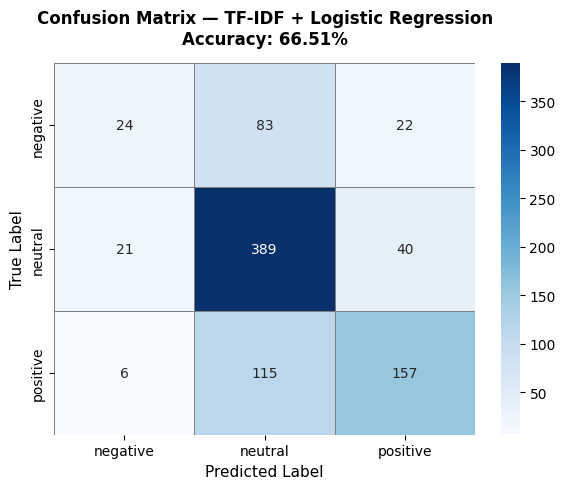

0.6651108518086347

In [ ]:
lr_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True, stop_words='english',
        ngram_range=(1, 2), min_df=5, max_df=0.9
    )),
    ('logreg', LogisticRegression(
        max_iter=2000, multi_class='multinomial',
        solver='lbfgs', n_jobs=-1
    ))
])
lr_pipe.fit(X_train, y_train)

y_pred_lr = lr_pipe.predict(X_test)
evaluate_model('TF-IDF + Logistic Regression', y_test, y_pred_lr, color='Blues')

## Hybrid SVM + Lexicon

Running Hybrid SVM predictions (may take a minute)...
  Hybrid SVM + Lexicon
  Accuracy : 0.6756 (67.56%)
  Macro F1 : 0.5607

              precision    recall  f1-score   support

    negative       0.42      0.19      0.27       129
     neutral       0.68      0.86      0.76       450
    positive       0.73      0.59      0.65       278

    accuracy                           0.68       857
   macro avg       0.61      0.55      0.56       857
weighted avg       0.66      0.68      0.65       857



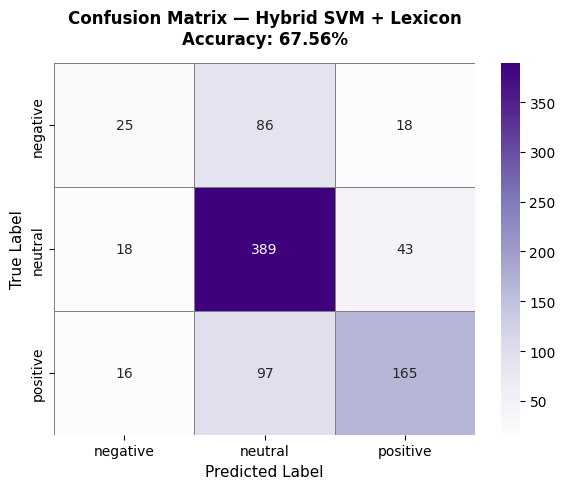

0.67561260210035

In [ ]:
svm_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english', ngram_range=(1, 2),
        min_df=3, max_df=0.9
    )),
    ('svm', SVC(kernel='linear', probability=True))
])
svm_pipe.fit(X_train, y_train)

# Keyword boost (same as your original)
strong_neg_words = {
    'crashed', 'crash', 'plummeted', 'plummet', 'losses', 'loss',
    'fell sharply', 'tumbled', 'panic', 'panicking', 'collapsed',
    'scandal', 'bankrupt', 'bankruptcy'
}
strong_pos_words = {
    'smashed expectations', 'beat expectations', 'soared', 'jumped',
    'surged', 'record profits', 'strong growth', 'optimistic',
    'bullish', 'rallied', 'rebounded'
}

def svm_with_lexicon_boost(text, boost=0.5):
    base_proba = svm_pipe.predict_proba([text])[0]
    classes = svm_pipe.classes_
    prob_dict = dict(zip(classes, base_proba))
    t = text.lower()
    if any(w in t for w in strong_neg_words):
        prob_dict['negative'] += boost
    if any(w in t for w in strong_pos_words):
        prob_dict['positive'] += boost
    total = sum(prob_dict.values())
    prob_dict = {k: v/total for k, v in prob_dict.items()}
    return max(prob_dict, key=prob_dict.get)

print('Running Hybrid SVM predictions (may take a minute)...')
y_pred_svm = [svm_with_lexicon_boost(t) for t in X_test]
evaluate_model('Hybrid SVM + Lexicon', y_test, y_pred_svm, color='Purples')

## FinBERT Baseline

Loading FinBERT Baseline...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Running FinBERT Baseline on 857 samples...
  FinBERT Baseline
  Accuracy : 0.7468 (74.68%)
  Macro F1 : 0.7278

              precision    recall  f1-score   support

    negative       0.52      0.83      0.64       129
     neutral       0.80      0.75      0.77       450
    positive       0.86      0.70      0.77       278

    accuracy                           0.75       857
   macro avg       0.72      0.76      0.73       857
weighted avg       0.78      0.75      0.75       857



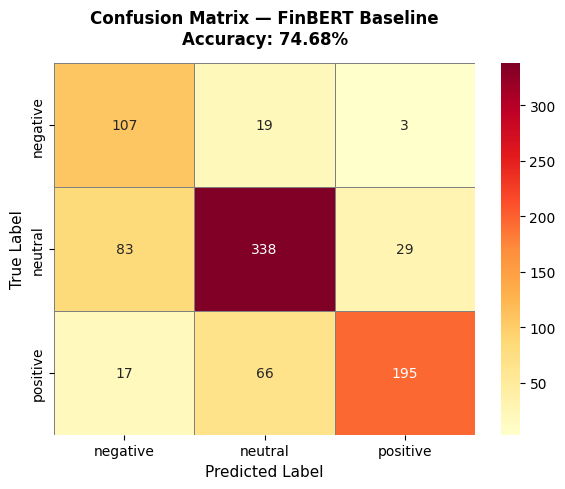

0.7467911318553092

In [ ]:
print('Loading FinBERT Baseline...')
fb_tokenizer = AutoTokenizer.from_pretrained('ProsusAI/finbert')
fb_model = AutoModelForSequenceClassification.from_pretrained('ProsusAI/finbert')

label_map = {0: 'positive', 1: 'negative', 2: 'neutral'}
fb_model.config.id2label = label_map
fb_model.config.label2id = {v: k for k, v in label_map.items()}

finbert_pipe = pipeline(
    'text-classification', model=fb_model, tokenizer=fb_tokenizer,
    device=0 if torch.cuda.is_available() else -1,
    truncation=True, max_length=512, batch_size=32
)

print(f'Running FinBERT Baseline on {len(X_test)} samples...')
preds = finbert_pipe(X_test.tolist())
y_pred_fb_base = [p['label'].lower().strip() for p in preds]
evaluate_model('FinBERT Baseline', y_test, y_pred_fb_base, color='YlOrRd')

## FinBERT Finetuned

Loading FinBERT Finetuned...


config.json:   0%|          | 0.00/845 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Running FinBERT Finetuned on 857 samples...
  FinBERT Finetuned
  Accuracy : 0.8938 (89.38%)
  Macro F1 : 0.8744

              precision    recall  f1-score   support

    negative       0.65      0.92      0.76       129
     neutral       0.95      0.85      0.90       450
    positive       0.97      0.96      0.96       278

    accuracy                           0.89       857
   macro avg       0.86      0.91      0.87       857
weighted avg       0.91      0.89      0.90       857



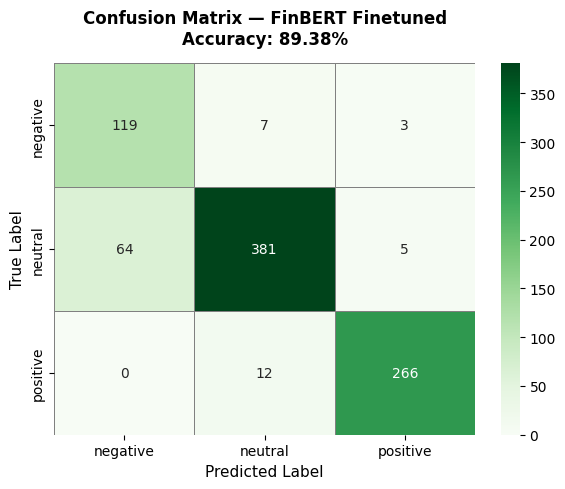

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ FinBERT Finetuned saved to finbert_finetuned/
  adding: finbert_finetuned/ (stored 0%)
  adding: finbert_finetuned/model.safetensors (deflated 7%)
  adding: finbert_finetuned/tokenizer_config.json (deflated 52%)
  adding: finbert_finetuned/tokenizer.json (deflated 71%)
  adding: finbert_finetuned/config.json (deflated 54%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ finbert_finetuned.zip downloaded!


In [ ]:
print('Loading FinBERT Finetuned...')
ft_tokenizer = AutoTokenizer.from_pretrained('project-aps/finbert-finetune')
ft_model = AutoModelForSequenceClassification.from_pretrained('project-aps/finbert-finetune')

label_map_ft = {0: 'neutral', 1: 'negative', 2: 'positive'}
ft_model.config.id2label = label_map_ft
ft_model.config.label2id = {v: k for k, v in label_map_ft.items()}

finbert_ft_pipe = pipeline(
    'text-classification', model=ft_model, tokenizer=ft_tokenizer,
    device=0 if torch.cuda.is_available() else -1,
    truncation=True, max_length=512, batch_size=32
)

print(f'Running FinBERT Finetuned on {len(X_test)} samples...')
preds_ft = finbert_ft_pipe(X_test.tolist())
y_pred_fb_ft = [p['label'].lower().strip() for p in preds_ft]
evaluate_model('FinBERT Finetuned', y_test, y_pred_fb_ft, color='Greens')

# ── Save FinBERT Finetuned model ──────────────────────────────────────────
import os
os.makedirs('finbert_finetuned', exist_ok=True)
ft_model.save_pretrained('finbert_finetuned')
ft_tokenizer.save_pretrained('finbert_finetuned')
print('✅ FinBERT Finetuned saved to finbert_finetuned/')

# Zip and download
!zip -r finbert_finetuned.zip finbert_finetuned/
from google.colab import files
files.download('finbert_finetuned.zip')
print('✅ finbert_finetuned.zip downloaded!')


## Final Comparison

  MODEL COMPARISON SUMMARY
                             accuracy f1_macro f1_negative f1_neutral f1_positive
FinBERT Finetuned              89.38%   87.44%      76.28%     89.65%      96.38%
FinBERT Baseline               74.68%   72.78%      63.69%     77.43%      77.23%
Hybrid SVM + Lexicon           67.56%   56.07%       26.6%     76.13%      65.48%
TF-IDF + Logistic Regression   66.51%   54.96%      26.67%     75.02%      63.18%
VADER (Lexicon)                51.23%    47.9%      36.44%     54.82%      52.43%



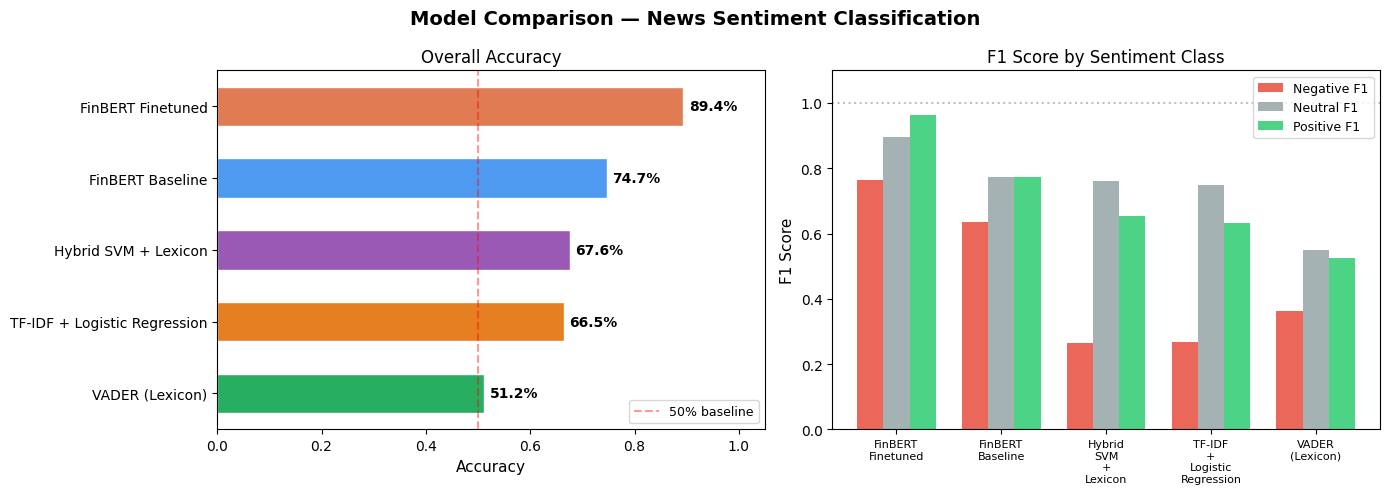

Chart saved as model_comparison.png


In [ ]:
# ── Summary Table ──────────────────────────────────────────────────────────
summary = pd.DataFrame(all_results).T
summary = summary.sort_values('accuracy', ascending=False)
summary_pct = summary.copy()
for col in summary_pct.columns:
    summary_pct[col] = (summary_pct[col] * 100).round(2).astype(str) + '%'

print('=' * 65)
print('  MODEL COMPARISON SUMMARY')
print('=' * 65)
print(summary_pct.to_string())
print()

# ── Bar Chart — Accuracy ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison — News Sentiment Classification', fontsize=14, fontweight='bold')

colors = ['#e07b54', '#4e9af1', '#9b59b6', '#e67e22', '#27ae60']
model_names = list(summary.index)
accuracies  = [summary.loc[m, 'accuracy'] for m in model_names]
f1_macros   = [summary.loc[m, 'f1_macro'] for m in model_names]

# Accuracy bar
bars = axes[0].barh(model_names, accuracies, color=colors, edgecolor='white', height=0.55)
axes[0].set_xlim(0, 1.05)
axes[0].set_xlabel('Accuracy', fontsize=11)
axes[0].set_title('Overall Accuracy', fontsize=12)
for bar, val in zip(bars, accuracies):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val*100:.1f}%', va='center', fontsize=10, fontweight='bold')
axes[0].axvline(x=0.5, color='red', linestyle='--', alpha=0.4, label='50% baseline')
axes[0].legend(fontsize=9)
axes[0].invert_yaxis()

# F1 per class grouped bar
x = np.arange(len(model_names))
width = 0.25
f1_neg = [summary.loc[m, 'f1_negative'] for m in model_names]
f1_neu = [summary.loc[m, 'f1_neutral']  for m in model_names]
f1_pos = [summary.loc[m, 'f1_positive'] for m in model_names]

axes[1].bar(x - width, f1_neg, width, label='Negative F1', color='#e74c3c', alpha=0.85)
axes[1].bar(x,          f1_neu, width, label='Neutral F1',  color='#95a5a6', alpha=0.85)
axes[1].bar(x + width,  f1_pos, width, label='Positive F1', color='#2ecc71', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=8)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('F1 Score', fontsize=11)
axes[1].set_title('F1 Score by Sentiment Class', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].axhline(y=1.0, color='grey', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()
print('Chart saved as model_comparison.png')

## Side-by-Side Confusion Matrices

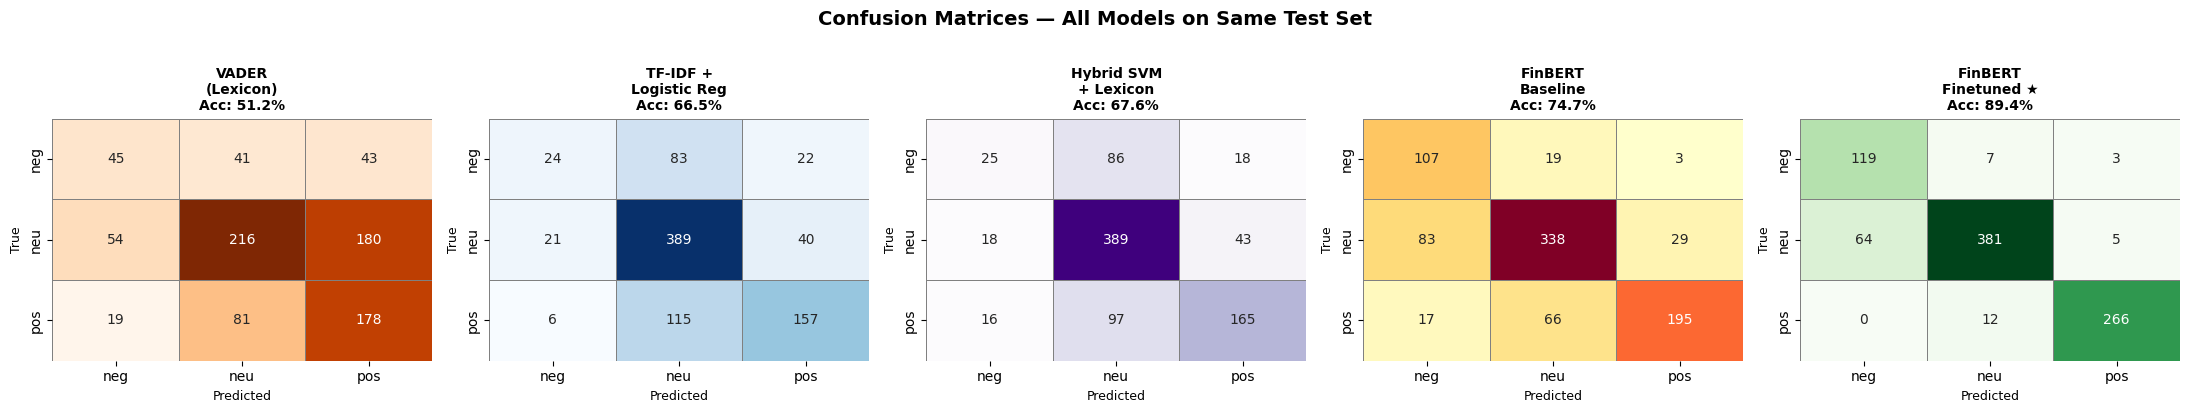

Saved as confusion_matrices_all.png


In [ ]:
all_preds = [
    ('VADER\n(Lexicon)',             y_pred_vader,   'Oranges'),
    ('TF-IDF +\nLogistic Reg',      y_pred_lr,      'Blues'),
    ('Hybrid SVM\n+ Lexicon',       y_pred_svm,     'Purples'),
    ('FinBERT\nBaseline',           y_pred_fb_base, 'YlOrRd'),
    ('FinBERT\nFinetuned ★',        y_pred_fb_ft,   'Greens'),
]

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('Confusion Matrices — All Models on Same Test Set', fontsize=14, fontweight='bold', y=1.02)

for ax, (name, y_pred, cmap) in zip(axes, all_preds):
    cm = confusion_matrix(y_test, y_pred, labels=LABELS)
    acc = accuracy_score(y_test, y_pred)

    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap,
        xticklabels=['neg', 'neu', 'pos'],
        yticklabels=['neg', 'neu', 'pos'],
        linewidths=0.5, linecolor='grey',
        ax=ax, cbar=False
    )
    ax.set_title(f'{name}\nAcc: {acc*100:.1f}%', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)

plt.tight_layout()
plt.show()
print('Saved as confusion_matrices_all.png')

In [ ]:
import zipfile
import os

# Unzip first
with zipfile.ZipFile('finbert_finetuned.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

print('✅ Unzipped!')

# Then load normally
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

device = 0 if torch.cuda.is_available() else -1

tokenizer = AutoTokenizer.from_pretrained('finbert_finetuned')
model = AutoModelForSequenceClassification.from_pretrained('finbert_finetuned')

label_map = {0: 'neutral', 1: 'negative', 2: 'positive'}
model.config.id2label = label_map
model.config.label2id = {v: k for k, v in label_map.items()}

classifier = pipeline('text-classification', model=model, tokenizer=tokenizer, device=device)

print('✅ Model loaded! Type your sentence below.')

# ── Type your own sentence ────────────────────────────────────────
while True:
    text = input('\nEnter a sentence (or type quit to stop): ')
    if text.lower() == 'quit':
        break
    result = classifier(text, truncation=True, max_length=512)[0]
    print(f'Sentiment  : {result["label"].upper()}')
    print(f'Confidence : {result["score"]*100:.1f}%')

✅ Unzipped!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Model loaded! Type your sentence below.

Enter a sentence (or type quit to stop): War left Iran in ruin
Sentiment  : NEUTRAL
Confidence : 99.0%

Enter a sentence (or type quit to stop): quit
